# 00 · Synthetic SkillData v1 dataset

**Task 3.9 / 3.10.** This notebook loads and explores the synthetic motor-capture dataset generated by
`skilldata.generate_synthetic` (run `make synthetic`, or
`uv run python -m skilldata.generate_synthetic --out data/processed`).

The dataset is **≥1000 trials** spread across the four motion classes — `reach`, `lift`,
`wrist_rotate`, `throw` — simulated on the 7-DOF human arm (`sim.arm3d.human_arm_7dof`). Each trial is
written in **two variants**:

- **clean** — ideal IMU streams (the noiseless ground truth, for fusion validation).
- **noisy** — the same motion through the D2 sensor model: gyro/accel white noise + gyro bias drift +
  hard saturation to ±2000 °/s / ±16 g, with a per-sample `saturation_flag` (what the real 4-IMU
  sleeve would produce).

The captured hand path is retargeted onto the reference humanoid robot (`reference_humanoid_7dof`) via
damped-least-squares IK and stored in each record's `retarget` layer.

Sensors: **S2** (upper-arm), **S4** (forearm), **S5** (hand). We cover: per-class stats, sample joint
trajectories, clean-vs-noisy IMU noise, the cheap-gyro **saturation envelope** (only `throw` trips it),
and the retarget IK quality.

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Resolve the dataset dir whether the notebook runs from repo root or notebooks/.
DATA = Path("data/processed")
if not (DATA / "manifest.json").exists():
    DATA = Path("..") / "data" / "processed"
manifest = json.loads((DATA / "manifest.json").read_text())
CLASSES = manifest["motion_classes"]
gen = manifest["generator"]
print(f"records: {manifest['n_records']}  |  base trials: {manifest['n_base_trials']}  "
      f"|  seed: {gen['seed']}  |  fs: {gen['sample_rate_hz']:.0f} Hz")
print(f"variants: {gen['variants']}  |  retarget robot: {gen['retarget_robot']}")
print(f"sensor model (D2): {gen['sensor_model']}")

Matplotlib is building the font cache; this may take a moment.


records: 2000  |  base trials: 1000  |  seed: 0  |  fs: 500 Hz
variants: ['clean', 'noisy']  |  retarget robot: reference_humanoid_7dof
sensor model (D2): {'gyro_noise_dps': 0.1, 'accel_noise_g': 0.01, 'initial_gyro_bias_dps': 0.5, 'gyro_bias_drift_dps_per_sqrt_s': 0.02, 'gyro_range_dps': 2000.0, 'accel_range_g': 16.0}


## 1 · Dataset composition and per-class envelope

In [2]:
# Per-class summary table straight from the manifest (aggregated at generation time).
hdr = f"{'class':13s} {'trials':>6s} {'peak|gyro| S2':>13s} {'S4':>8s} {'S5':>8s} " \
      f"{'sat.recs':>8s} {'sat.frac':>8s}"
print(hdr); print("-" * len(hdr))
for mc in CLASSES:
    c = manifest["per_class"][mc]
    pg = c["peak_gyro_dps"]
    print(f"{mc:13s} {c['n_trials']:6d} {pg.get('S2',0):13.0f} {pg.get('S4',0):8.0f} "
          f"{pg.get('S5',0):8.0f} {c['saturated_records']:8d} {c['saturation_frac']:8.4f}")
print("\nNote:", manifest["saturation_note"])

class         trials peak|gyro| S2       S4       S5 sat.recs sat.frac
----------------------------------------------------------------------
reach            250           149      308      308        0   0.0000
lift             250            95      162      162        0   0.0000
wrist_rotate     250             0      118      323        0   0.0000
throw            250          1066     1957     3514      250   0.0356

Note: Only 'throw' peaks past the D2 +-2000 deg/s gyro range (distal wrist sensor S5 ~3000 deg/s); reach/lift/wrist_rotate stay inside the envelope. This is the documented cheap-gyro limit.


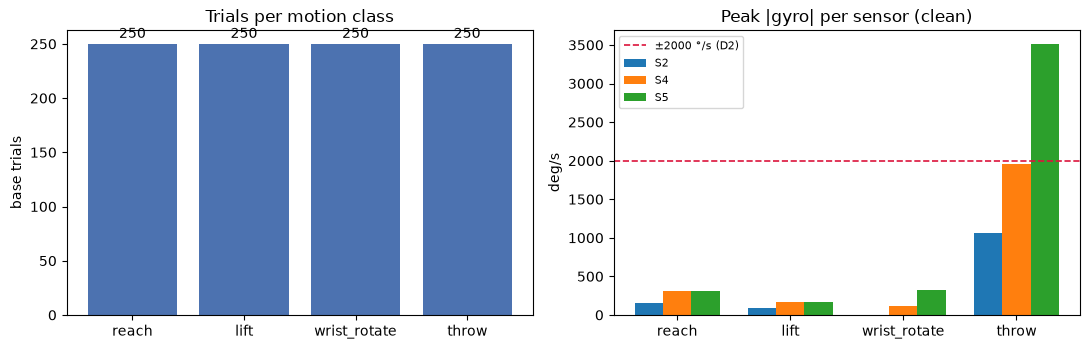

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
counts = [manifest["per_class"][mc]["n_trials"] for mc in CLASSES]
ax[0].bar(CLASSES, counts, color="#4C72B0")
ax[0].set_title("Trials per motion class"); ax[0].set_ylabel("base trials")
for i, v in enumerate(counts):
    ax[0].text(i, v + max(counts) * 0.01, str(v), ha="center", va="bottom")

# Peak |gyro| per sensor per class (from clean ground truth), with the ±2000°/s D2 line.
sensors = ["S2", "S4", "S5"]
x = np.arange(len(CLASSES)); w = 0.25
for j, s in enumerate(sensors):
    vals = [manifest["per_class"][mc]["peak_gyro_dps"].get(s, 0) for mc in CLASSES]
    ax[1].bar(x + (j - 1) * w, vals, w, label=s)
ax[1].axhline(2000, color="crimson", ls="--", lw=1.2, label="±2000 °/s (D2)")
ax[1].set_xticks(x); ax[1].set_xticklabels(CLASSES)
ax[1].set_title("Peak |gyro| per sensor (clean)"); ax[1].set_ylabel("deg/s"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 2 · Sample joint trajectories per motion class
One representative trial per class — the joints each class actually drives (min-jerk, rest→active→rest).

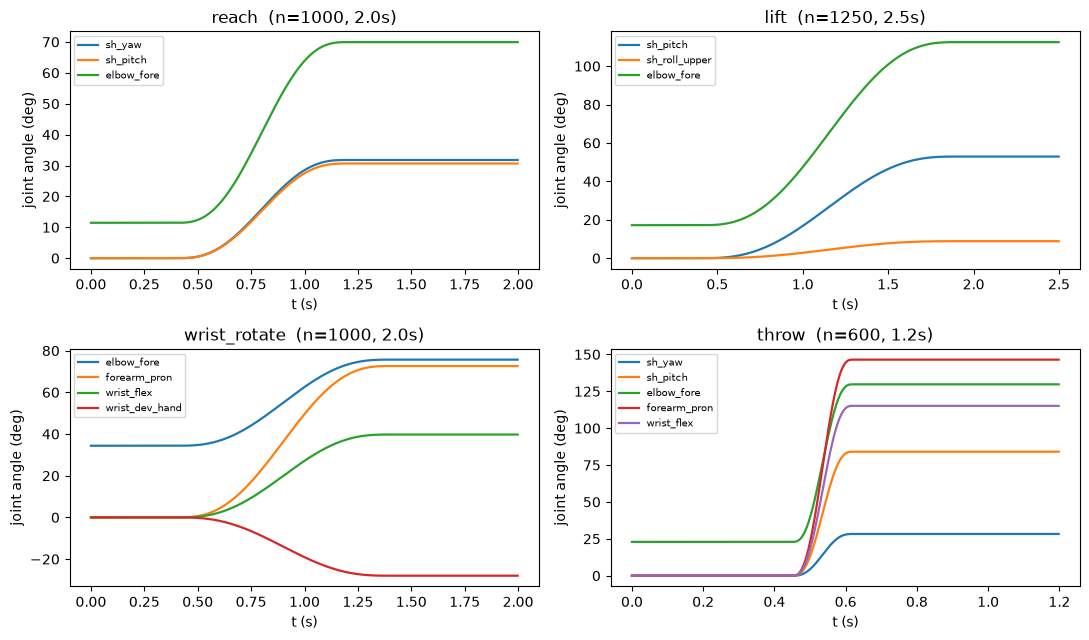

In [4]:
def load(mc, variant="clean", idx=0):
    return json.loads((DATA / f"S001_{mc}_{variant}_{idx:04d}.json").read_text())

JOINT_NAMES = ["sh_yaw", "sh_pitch", "sh_roll_upper", "elbow_fore",
               "forearm_pron", "wrist_flex", "wrist_dev_hand"]
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex=False)
for ax, mc in zip(axes.ravel(), CLASSES):
    rec = load(mc)
    ja = rec["segment_kinematics"]["joint_angles_rad"]
    fs = rec["session"]["sample_rate_hz"]
    t = np.arange(rec["session"]["n_samples"]) / fs
    for name in JOINT_NAMES:
        q = np.asarray(ja[name])
        if np.abs(q).max() > 1e-6:                       # only the joints this class moves
            ax.plot(t, np.rad2deg(q), label=name, lw=1.6)
    ax.set_title(f"{mc}  (n={rec['session']['n_samples']}, {t[-1]:.1f}s)")
    ax.set_xlabel("t (s)"); ax.set_ylabel("joint angle (deg)"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 3 · IMU noise — clean vs noisy
The sensor model adds white noise + bias drift on top of the ideal signal. Forearm sensor **S4** on a `reach` trial.

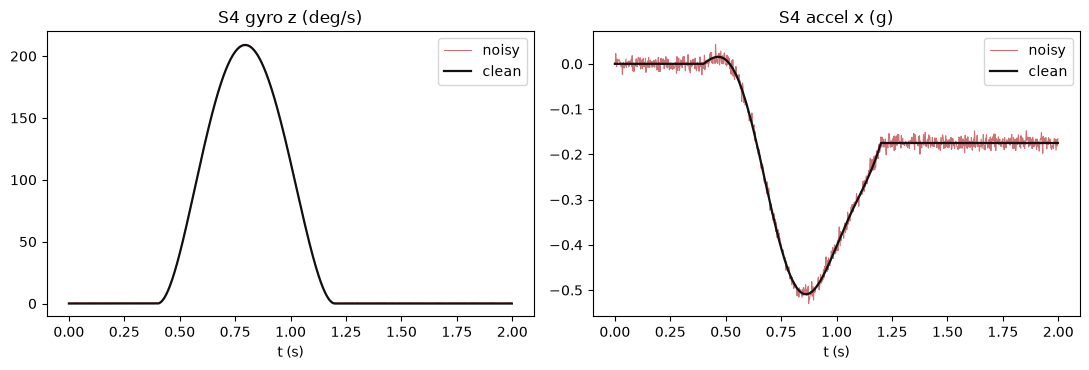

gyro noise: measured std = 0.103 deg/s (model gyro_noise_dps + bias drift)


In [5]:
clean = load("reach", "clean"); noisy = load("reach", "noisy")
fs = clean["session"]["sample_rate_hz"]
t = np.arange(clean["session"]["n_samples"]) / fs
gc = np.asarray(clean["imu_streams"]["S4"]["angular_velocity_dps"])
gn = np.asarray(noisy["imu_streams"]["S4"]["angular_velocity_dps"])
ac = np.asarray(clean["imu_streams"]["S4"]["linear_accel_g"])
an = np.asarray(noisy["imu_streams"]["S4"]["linear_accel_g"])

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(t, gn[:, 2], color="#C44E52", lw=0.8, alpha=0.8, label="noisy")
ax[0].plot(t, gc[:, 2], color="#111111", lw=1.6, label="clean")
ax[0].set_title("S4 gyro z (deg/s)"); ax[0].set_xlabel("t (s)"); ax[0].legend()
ax[1].plot(t, an[:, 0], color="#C44E52", lw=0.8, alpha=0.8, label="noisy")
ax[1].plot(t, ac[:, 0], color="#111111", lw=1.6, label="clean")
ax[1].set_title("S4 accel x (g)"); ax[1].set_xlabel("t (s)"); ax[1].legend()
plt.tight_layout(); plt.show()

# residual noise magnitude vs the model's stated std
res = gn[:, 2] - gc[:, 2]
print(f"gyro noise: measured std = {res.std():.3f} deg/s (model gyro_noise_dps + bias drift)")

## 4 · The cheap-gyro saturation envelope
Decision **D2** keeps the low-cost ICM-42688-P at ±2000 °/s. Only the fast **throw** drives the distal
hand sensor **S5** past that range — those samples pin and are flagged invalid. The three slower
classes stay inside the envelope. This is the documented limitation, made visible.

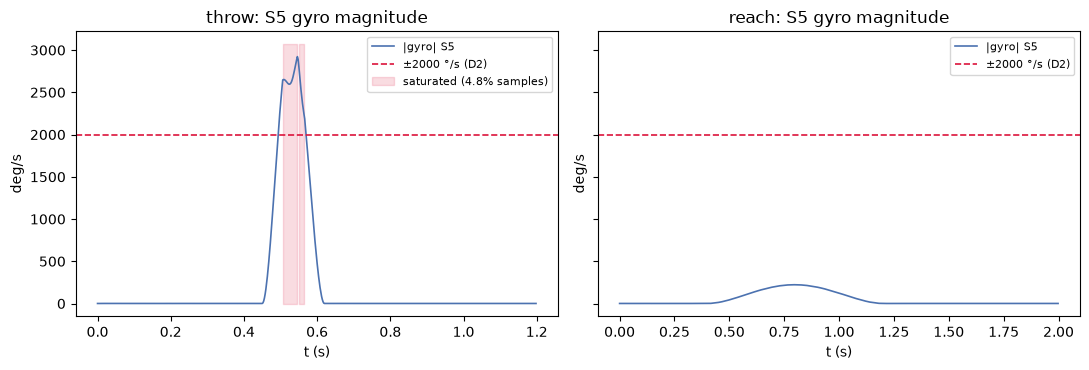

In [6]:
thr = load("throw", "noisy")
rch = load("reach", "noisy")
def gyro_mag(rec, sid):
    g = np.asarray(rec["imu_streams"][sid]["angular_velocity_dps"])
    return np.linalg.norm(g, axis=-1)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for a, rec, name in ((ax[0], thr, "throw"), (ax[1], rch, "reach")):
    fs = rec["session"]["sample_rate_hz"]; t = np.arange(rec["session"]["n_samples"]) / fs
    mag = gyro_mag(rec, "S5")
    flag = np.asarray(rec["imu_streams"]["S5"]["saturation_flag"], bool)
    a.plot(t, mag, color="#4C72B0", lw=1.2, label="|gyro| S5")
    a.axhline(2000, color="crimson", ls="--", lw=1.2, label="±2000 °/s (D2)")
    if flag.any():
        a.fill_between(t, 0, mag.max() * 1.05, where=flag, color="crimson", alpha=0.15,
                       label=f"saturated ({flag.mean()*100:.1f}% samples)")
    a.set_title(f"{name}: S5 gyro magnitude"); a.set_xlabel("t (s)"); a.set_ylabel("deg/s")
    a.legend(fontsize=8)
plt.tight_layout(); plt.show()

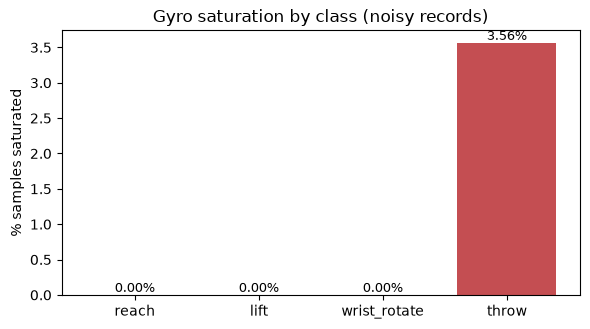

In [7]:
# Saturation fraction per class, aggregated across all noisy records (from the manifest).
fig, ax = plt.subplots(figsize=(6, 3.4))
fracs = [manifest["per_class"][mc]["saturation_frac"] * 100 for mc in CLASSES]
bars = ax.bar(CLASSES, fracs, color=["#55A868" if f == 0 else "#C44E52" for f in fracs])
ax.set_ylabel("% samples saturated"); ax.set_title("Gyro saturation by class (noisy records)")
for b, f in zip(bars, fracs):
    ax.text(b.get_x() + b.get_width() / 2, f, f"{f:.2f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

## 5 · Retarget quality (robot-ready layer)
Per-record IK residual (max over the trial) and reachable fraction, read from the manifest — the humanoid reproduces the captured hand path to sub-cm.

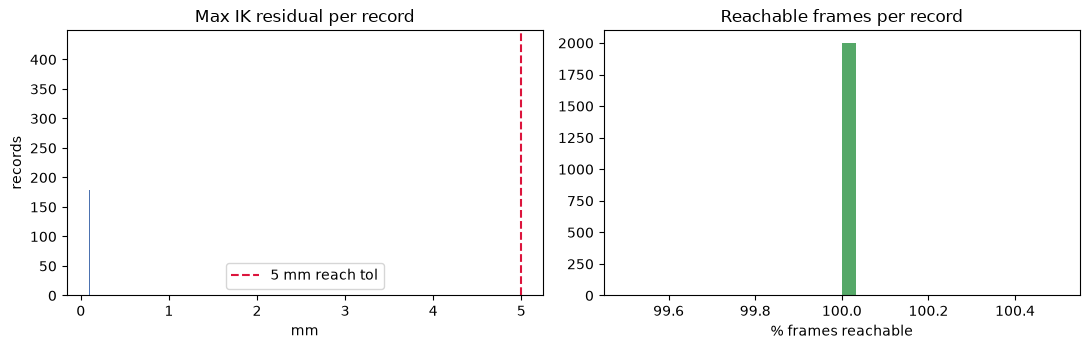

median max-residual = 0.10 mm | mean reachable = 100.0% over 2000 records


In [8]:
rt = [e for e in manifest["trials"] if "max_ik_residual_m" in e]
if rt:
    res_mm = np.array([e["max_ik_residual_m"] for e in rt]) * 1e3
    reach = np.array([e["frac_reachable"] for e in rt])
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
    ax[0].hist(res_mm, bins=40, color="#4C72B0")
    ax[0].set_title("Max IK residual per record"); ax[0].set_xlabel("mm"); ax[0].set_ylabel("records")
    ax[0].axvline(5.0, color="crimson", ls="--", label="5 mm reach tol"); ax[0].legend()
    ax[1].hist(reach * 100, bins=30, color="#55A868")
    ax[1].set_title("Reachable frames per record"); ax[1].set_xlabel("% frames reachable")
    plt.tight_layout(); plt.show()
    print(f"median max-residual = {np.median(res_mm):.2f} mm | "
          f"mean reachable = {reach.mean()*100:.1f}% over {len(rt)} records")
else:
    print("No retarget layer in this dataset (generated with --no-retarget).")

## 6 · Phase-label composition
Every sample is labelled `prep` / `active` / `settle` from joint speed. Fraction of each phase, from one trial per class.

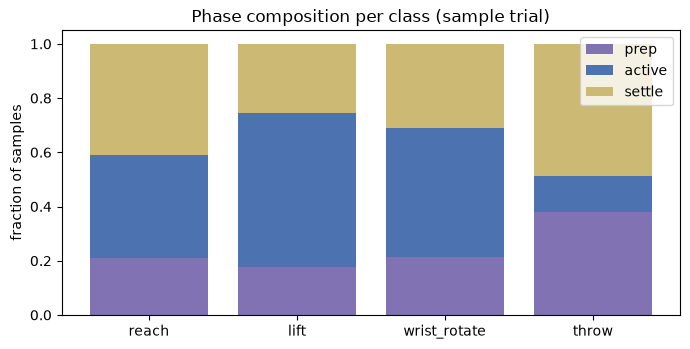

In [9]:
phases = ["prep", "active", "settle"]
comp = {mc: {p: 0 for p in phases} for mc in CLASSES}
for mc in CLASSES:
    lab = load(mc)["phase_labels"]
    for p in phases:
        comp[mc][p] = lab.count(p) / len(lab)
fig, ax = plt.subplots(figsize=(7, 3.6))
bottom = np.zeros(len(CLASSES))
colors = {"prep": "#8172B3", "active": "#4C72B0", "settle": "#CCB974"}
for p in phases:
    vals = np.array([comp[mc][p] for mc in CLASSES])
    ax.bar(CLASSES, vals, bottom=bottom, label=p, color=colors[p]); bottom += vals
ax.set_ylabel("fraction of samples"); ax.set_title("Phase composition per class (sample trial)")
ax.legend(); plt.tight_layout(); plt.show()

## Summary

- **≥1000 trials** across four motion classes, each in **clean** (ground-truth) and **noisy**
  (D2 sensor model) variants, retargeted onto the reference humanoid — all validated against
  SkillData v1 `schema.json`.
- **Noise** is visible on top of the ideal signal; the measured gyro-noise std matches the model.
- **Saturation envelope:** only `throw` pins the distal hand gyro **S5** past ±2000 °/s — the
  documented cheap-gyro limit (D2). The slower classes are clean.
- **Retarget** reproduces the captured hand path to sub-centimetre residual on essentially every frame.

This dataset is the input to fusion validation (Phase 4) and the HNN/pHNN modeling core (Phase 5).